## Pandora $\nu_e$CCN$p$0$\pi^{\pm}$ selection

In [1]:
# io
import os
import sys
import pickle
import uproot

# thanks pandas for existing
import pandas
pandas.set_option('display.max_columns', None)
import numpy
import scipy

# plotting
import matplotlib
import matplotlib.pyplot as plt

# my stuff
import cuts
import truthcuts as tcuts
import plotting

# pyanalib helpers
CAFPYANA_PATH = '/exp/icarus/app/users/rtriozzi/cafpyana/'
sys.path.append(CAFPYANA_PATH)
import pyanalib.pandas_helpers

#### Load data

In [42]:
# check keys
# pandas.HDFStore(f"{CAFPYANA_PATH}/test_pandora.df").keys()

In [2]:
CAFPYANA_PATH = '/exp/icarus/app/users/rtriozzi/cafpyana/'
DF_PATH       = f'{CAFPYANA_PATH}/NuMI_NuE_v10_06_00_01p01_1D_ElectronInfo_v2.df'
evtdf = pandas.read_hdf(f'{DF_PATH}', key='evt_0')
hdrdf = pandas.read_hdf(DF_PATH, key='hdr_0')
mcnudf = pandas.read_hdf(DF_PATH, key='mcnu_0')
potdf = pandas.read_hdf(DF_PATH, key='pot_0')
crtpmtdf = pandas.read_hdf(DF_PATH, key='crtpmt_0')

In [3]:
### merge truth and reco

matchdf = pyanalib.pandas_helpers.multicol_merge(
    evtdf.reset_index(), mcnudf.reset_index(),
    left_on=[("entry", "",""), ("slc","tmatch", "idx", "", "", "")],
    right_on=[("entry", "",""), ("rec.mc.nu..index", "","")], 
    how="left"
) # save all slices!

/exp/icarus/app/users/rtriozzi/cafpyana/pyanalib/pandas_helpers.py:85: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)
/exp/icarus/app/users/rtriozzi/cafpyana/pyanalib/pandas_helpers.py:85: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


In [3]:
### add CRT-PMT veto at the slice level

# we want only spills with at least contained flashes
crtpmtdf[("contained_flash")] = (crtpmtdf.flashGateTime > 0) & (crtpmtdf.flashGateTime < 9.8) & (crtpmtdf.flashClassification == 0)
crtpmt_veto = crtpmtdf.groupby(["__ntuple", "entry"])["contained_flash"].any()
crtpmt_veto.name = ("crtpmt_veto")

# add to the event df
evtdf = pyanalib.pandas_helpers.multicol_add(
    evtdf,
    crtpmt_veto,
    default = False
)

#### Event selection

In [4]:
def SplitByCut(
    df,
    selection,
    var,
    mycuts
):
    cutDFs = []
    
    for cut in mycuts:
        if selection is None:
            cutDFs.append(df.loc[cut, var])
        else:
            cutDFs.append(df.loc[selection & cut, var])

    return cutDFs

/tmp/ipykernel_69626/1045215350.py:8: PerformanceWarning: indexing past lexsort depth may impact performance.
  n, bins, _ = ax.hist(evtdf.loc[:, var], bins=binning, ec='black', lw=1.5, histtype='step', label='all $\\nu$-slices')
/home/rtriozzi/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/rtriozzi/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))
/home/rtriozzi/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/numpy/lib/histograms.py:461: RuntimeWarning: invalid value encountered in cast
  a.searchsorted(v[:-1], 'left'),
/home/rtriozzi/cafpyana/envs/venv_py39_cafpyana/lib/python3.9/site-packages/numpy/lib/histograms.py:462: RuntimeWarning: invalid value encountered in cast
  a.searchsorted(v[-1:], 'right')


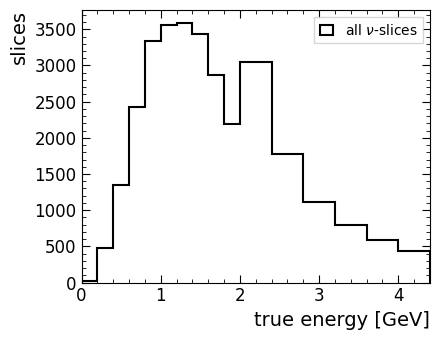

In [5]:
fig, ax = plt.subplots(figsize = (4.5, 3.5), layout = 'tight')
var = ("slc", "truth", "E")

binning = numpy.concatenate(
    (numpy.arange(0, 2+0.2, 0.2),
    numpy.arange(2+0.4, 4+0.4, 0.4))
)
n, bins, _ = ax.hist(evtdf.loc[:, var], bins=binning, ec='black', lw=1.5, histtype='step', label='all $\\nu$-slices')

plotting.UpdateMatplotlibStyle(ax, "true energy [GeV]", "slices")
ax.set_xlim(bins[0], bins[-1])
plt.show()

In [6]:
channels = ['$\\nu_e$CC', '$\\nu_\mu$CC', '$\\nu$NC', 'OoFV', 'Cosmic']
mycuts = [
    tcuts.kIsNuE(evtdf) & tcuts.kIsCC(evtdf),
    tcuts.kIsNuMu(evtdf) & tcuts.kIsCC(evtdf),
    ~tcuts.kIsCC(evtdf) & tcuts.kIsTrueFV(evtdf),
    ~tcuts.kIsTrueFV(evtdf) & tcuts.kIsNu(evtdf),
    ~tcuts.kIsNu(evtdf)
]

/tmp/ipykernel_69626/560705980.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  cutDFs.append(df.loc[cut, var])
/tmp/ipykernel_69626/565618286.py:10: PerformanceWarning: indexing past lexsort depth may impact performance.
  n, bins, _ = ax.hist(evtdf.loc[tcuts.kIsSignal(evtdf), var], bins=numpy.arange(0, 4+width, width), histtype='step', lw=2, ec='red', label='Signal: 1$e$N$p$0$\\pi$')


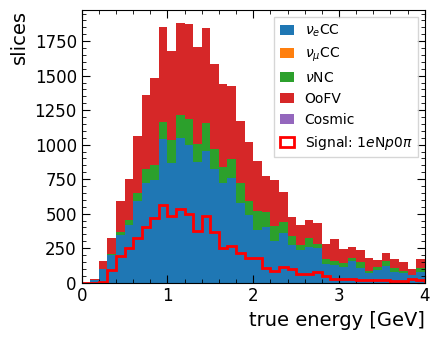

In [7]:
fig, ax = plt.subplots(figsize = (4.5, 3.5), layout = 'tight')
var = ("slc","truth","E")
# var = ("pfp","shw","plane", "I2", "nHits")

width = 0.1
evtdf_split = SplitByCut(evtdf, None, var, mycuts)
n, bins, _ = ax.hist(evtdf_split, bins=numpy.arange(0, 4+width, width), stacked=True, label=channels)

# signal
n, bins, _ = ax.hist(evtdf.loc[tcuts.kIsSignal(evtdf), var], bins=numpy.arange(0, 4+width, width), histtype='step', lw=2, ec='red', label='Signal: 1$e$N$p$0$\\pi$')

#plt.yscale('log')
plotting.UpdateMatplotlibStyle(ax, "true energy [GeV]", "slices")
ax.set_xlim(bins[0], bins[-1])
plt.show()

/tmp/ipykernel_69626/560705980.py:11: PerformanceWarning: indexing past lexsort depth may impact performance.
  cutDFs.append(df.loc[cut, var])


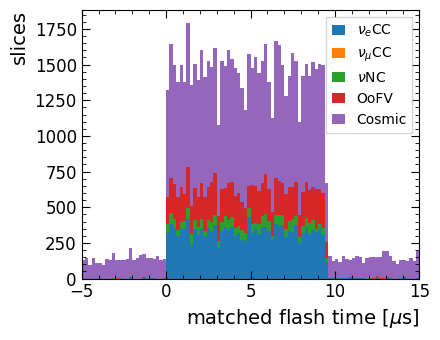

In [8]:
fig, ax = plt.subplots(figsize = (4.5, 3.5), layout = 'tight')
var = ("slc","barycenterFM","flashTime")

width = 0.2
evtdf_split = SplitByCut(evtdf, None, var, mycuts)
n, bins, _ = plt.hist(evtdf_split, bins=numpy.arange(-5, 15+width, width), stacked=True, label=channels)
plt.legend()

plotting.UpdateMatplotlibStyle(ax, "matched flash time [$\\mu$s]", "slices")
ax.set_xlim(bins[0], bins[-1])
plt.show()

/tmp/ipykernel_69626/960513556.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  evtdf.loc[truthcut, var],
/tmp/ipykernel_69626/960513556.py:49: PerformanceWarning: indexing past lexsort depth may impact performance.
  evtdf.loc[truthcut & recocut, var],


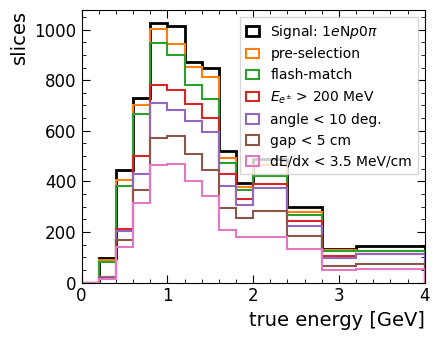

In [9]:
### selection progression on true spectrum of reconstructed interactions

fig, ax = plt.subplots(figsize=(4.5, 3.5), layout='tight')
var = ("slc", "truth", "E")

binning = numpy.concatenate((
    numpy.arange(0, 2+0.2, 0.2),
    numpy.arange(2+0.4, 2.8+0.4, 0.4),
    numpy.arange(3.2, 4+0.8, 0.8),
))

# truth
# truthcut = tcuts.kIsNuE(evtdf) & tcuts.kIsCC(evtdf)
truthcut = tcuts.kIsSignal(evtdf)
n_truth, bins, _ = ax.hist(
    evtdf.loc[truthcut, var],
    bins=binning, histtype='step', lw=2, ec='black', label='Signal: 1$e$N$p$0$\\pi$'
)
    
# reco
mycuts = [
    # ("CRT-PMT veto", cuts.kCRTPMTVeto),
    ("pre-selection",           lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df)),
    ("flash-match",             lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df) & cuts.kTrigFlashMatch(df)),
    ("$E_{e^{\pm}}$ > 200 MeV", lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df) & cuts.kTrigFlashMatch(df)
                                    & cuts.kLargestRecoShower_EnergyCut(df)),
    ("angle < 10 deg.",         lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df) & cuts.kTrigFlashMatch(df)
                                   & cuts.kLargestRecoShower_EnergyCut(df) & cuts.kLargestRecoShower_OpenAngleCut(df)),
    ("gap < 5 cm",              lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df) & cuts.kTrigFlashMatch(df)
                                   & cuts.kLargestRecoShower_EnergyCut(df) & cuts.kLargestRecoShower_OpenAngleCut(df)
                                   & cuts.kLargestRecoShower_ConvGapCut(df)),
    ("dE/dx < 3.5 MeV/cm",      lambda df: cuts.kVertexInFV(df) & cuts.kNotClearCosmic(df) & cuts.kTrigFlashMatch(df)
                                   & cuts.kLargestRecoShower_EnergyCut(df) & cuts.kLargestRecoShower_OpenAngleCut(df)
                                   & cuts.kLargestRecoShower_ConvGapCut(df) & cuts.kLargestRecoShower_dEdxCut(df)),
]

# save efficiency at each step
progressive_efficiency = {}
efficiency = {}
selected_events = {}

this_n = n_truth.copy()

for i, (label, cut) in enumerate(mycuts):

    # plot at this cut
    recocut = cut(evtdf)
    n_sel, bins, _ = plt.hist(
        evtdf.loc[truthcut & recocut, var],
        bins=binning, histtype='step', lw=1.5, label=label
    )

    # progressive efficiency
    with numpy.errstate(divide='ignore', invalid='ignore'):
        prog_eff = numpy.where(this_n > 0, n_sel / this_n, 0)
    progressive_efficiency[label] = prog_eff
    this_n = n_sel.copy()

    # efficiency
    with numpy.errstate(divide='ignore', invalid='ignore'):
        eff = numpy.where(n_truth > 0, n_sel / n_truth, 0)
    efficiency[label] = eff

    # store selected events for further processing
    selected_events[label] = n_sel
    
plotting.UpdateMatplotlibStyle(ax, "true energy [GeV]", "slices")
ax.set_xlim(bins[0], bins[-1])
plt.show()

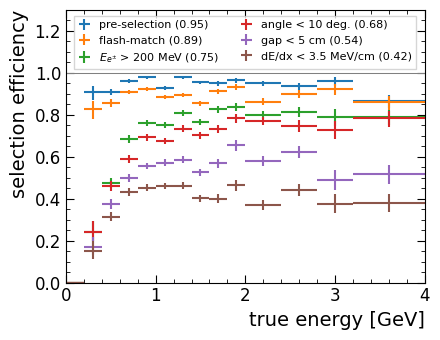

In [16]:
### selection efficiency w.r.t. true spectrum for reconstructed interactions

fig, ax = plt.subplots(figsize=(4.5, 3.5), layout='tight')

x = 0.5 * (binning[1:] + binning[:-1])
xerr = 0.5 * (binning[1:] - binning[:-1])

for step in selected_events:

    with numpy.errstate(divide='ignore', invalid='ignore'):
        # efficiency per-bin
        eff = numpy.where(n_truth > 0, selected_events[step] / n_truth, 0)
        
        alpha = 0.32 # 68% CL
        lower = scipy.stats.beta.ppf(alpha/2, selected_events[step], n_truth - selected_events[step] + 1)
        upper = scipy.stats.beta.ppf(1 - alpha/2, selected_events[step] + 1, n_truth - selected_events[step])
        yerr = numpy.array([selected_events[step] / n_truth - lower, upper - selected_events[step] / n_truth])
        
        # total efficiency
        tot_eff = selected_events[step].sum() / n_truth.sum()
    
    ax.errorbar(x, eff, xerr=xerr, yerr=yerr, marker='', ls='', label=step+f' ({tot_eff:.2g})')

ax.axhline(1, lw=0.75, c='gray')

plotting.UpdateMatplotlibStyle(ax, "true energy [GeV]", "selection efficiency", 
                              ncols=2, fontsize=8, loc='upper center')
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0, 1.3)
plt.show()

In [ ]:
### reconstructed variables with final selection

fig, ax = plt.subplots(figsize=(4.5, 3.5), layout='tight')

var = ("pfp","shw","plane", "I2", "energy")

binning = numpy.arange(0, 1.5+0.075, 0.075)

recocut = (cuts.kVertexInFV(evtdf) & cuts.kNotClearCosmic(evtdf) 
           & cuts.kTrigFlashMatch(evtdf) & cuts.kLargestRecoShower_EnergyCut(evtdf) & cuts.kLargestRecoShower_OpenAngleCut(evtdf)
           & cuts.kLargestRecoShower_ConvGapCut(evtdf) & cuts.kLargestRecoShower_dEdxCut(evtdf)) 

channelLabels = ['signal: 1$e$N$p$0$\\pi$', 'other $\\nu_e$CC', '$\\nu_\mu$CC', '$\\nu$NC', 'OoFV', 'cosmic']
channels = [
    tcuts.kIsSignal(evtdf), # signal is 1eNp0π
    ~tcuts.kIsSignal(evtdf) & tcuts.kIsNuE(evtdf) & tcuts.kIsCC(evtdf), # non-signal nueCCs in FV
    tcuts.kIsNuMu(evtdf) & tcuts.kIsCC(evtdf), # numuCCs in FV
    ~tcuts.kIsCC(evtdf) & tcuts.kIsTrueFV(evtdf), # NCs in FV
    ~tcuts.kIsTrueFV(evtdf) & tcuts.kIsNu(evtdf), # all nues outside of the FV
    ~tcuts.kIsNu(evtdf) # cosmics
]

evtdf_split = SplitByCut(evtdf, recocut, var, channels)
n, bins, _ = plt.hist(evtdf_split, bins=binning, stacked=True, label=channelLabels)

plotting.UpdateMatplotlibStyle(ax, "true energy [GeV]", "slices")
ax.set_xlim(bins[0], bins[-1])
plt.show()

In [ ]:
# to do: finish implementing cuts in cafpyana
# to do: develop efficiency analysis: look at matchdf, probably useful to select signal first so it's faster

In [7]:
# print(evtdf.columns.tolist())